In [17]:
import pandas as pd
import os
import yaml

In [18]:
augs_csv = pd.read_csv('/home/fsoto/Documents/LCsSSL/wandb_csv/augmentations_ablation.csv')
augs_csv_v2 = pd.read_csv('/home/fsoto/Documents/LCsSSL/wandb_csv/augmentations_ablation_v2.csv')

In [19]:
def find_config(pre_trained_lc_path, pre_trained_iteration):

    config_file = os.path.join(pre_trained_lc_path, str(pre_trained_iteration), '.hydra', 'config.yaml')
    config_file = config_file.replace('/train/multiruns/', '/backup/vicreg_simclr/')

    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    augs = config['data']['transform']['transform_list']
    first_aug = augs[0]
    if first_aug == '${first_transform}':
        augs = [config['first_transform']]
        augs.append(config['second_transform'])
    else:
        augs.append(config['data']['transform']['transform_list'][0])
    return augs
        

In [20]:
#apply the function to each row in the DataFrame and create a new column 'first_aug' and second column 'second_aug'
augs_csv['first_aug'] = augs_csv.apply(lambda row: find_config(row['model.pre_trained_lc_path'], row['model.pre_trained_iteration'])[0], axis=1) 
augs_csv['second_aug'] = augs_csv.apply(lambda row: find_config(row['model.pre_trained_lc_path'], row['model.pre_trained_iteration'])[1], axis=1) 

In [21]:
augs_csv_v2['first_aug'] = augs_csv_v2.apply(lambda row: find_config(row['model.pre_trained_lc_path'], row['model.pre_trained_iteration'])[0], axis=1)
augs_csv_v2['second_aug'] = augs_csv_v2.apply(lambda row: find_config(row['model.pre_trained_lc_path'], row['model.pre_trained_iteration'])[1], axis=1)

In [22]:
#calculate the mean f1 and std grouped by 'first_aug' and 'second_aug' in a new df
f1_stats = augs_csv.groupby(['first_aug', 'second_aug'])['val/f1'].agg(['mean', 'std']).reset_index()
f1_stats.columns = ['first_aug', 'second_aug', 'f1_mean', 'f1_std']

In [23]:
f1_stats_v2 = augs_csv_v2.groupby(['first_aug', 'second_aug'])['val/f1'].agg(['mean', 'std']).reset_index()
f1_stats_v2.columns = ['first_aug', 'second_aug', 'f1_mean', 'f1_std']

In [24]:
#remove. the columnns with masking in the name
f1_stats = f1_stats[~f1_stats['first_aug'].str.contains('masking')]
f1_stats = f1_stats[~f1_stats['second_aug'].str.contains('masking')].reset_index(drop=True)
#remove the columns with name time_shift
f1_stats = f1_stats[~f1_stats['first_aug'].str.contains('time_shift')]
f1_stats = f1_stats[~f1_stats['second_aug'].str.contains('time_shift')].reset_index(drop=True)


In [25]:
#concatenate the two dataframes
f1_stats = pd.concat([f1_stats, f1_stats_v2], ignore_index=True)

In [26]:
# Function to clean augmentation names
def clean_aug_name(name):
    """Remove underscores and capitalize words"""
    return ' '.join(word.capitalize() for word in name.split('_'))

# Apply cleaning to augmentation names
f1_stats['first_aug_clean'] = f1_stats['first_aug'].apply(clean_aug_name)
f1_stats['second_aug_clean'] = f1_stats['second_aug'].apply(clean_aug_name)

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [28]:
# Create pivot tables for mean F1 and std using cleaned names
f1_mean_pivot = f1_stats.pivot(index='first_aug_clean', columns='second_aug_clean', values='f1_mean')
f1_std_pivot = f1_stats.pivot(index='first_aug_clean', columns='second_aug_clean', values='f1_std')

# Order rows and columns by mean F1 score
# Calculate row means and column means for ordering
row_means = f1_mean_pivot.mean(axis=1).sort_values(ascending=False)
col_means = f1_mean_pivot.mean(axis=0).sort_values(ascending=False)

# Reorder the pivot tables
f1_mean_pivot_ordered = f1_mean_pivot.loc[row_means.index, col_means.index]
f1_std_pivot_ordered = f1_std_pivot.loc[row_means.index, col_means.index]

print("Row ordering (first_aug) by mean F1:")
for i, (aug, score) in enumerate(row_means.items()):
    print(f"{i+1}. {aug}: {score:.4f}")

print("\nColumn ordering (second_aug) by mean F1:")
for i, (aug, score) in enumerate(col_means.items()):
    print(f"{i+1}. {aug}: {score:.4f}")

# Display the ordered pivot table
print(f"\nOrdered F1 Mean Matrix:")
print(f1_mean_pivot_ordered.round(4))

Row ordering (first_aug) by mean F1:
1. Random Mask: 0.5912
2. Resampling: 0.5809
3. Random Noise: 0.5565
4. Channel Shuffle: 0.5302
5. Time Shift: 0.5288

Column ordering (second_aug) by mean F1:
1. Random Mask: 0.5935
2. Resampling: 0.5815
3. Random Noise: 0.5575
4. Channel Shuffle: 0.5297
5. Time Shift: 0.5255

Ordered F1 Mean Matrix:
second_aug_clean  Random Mask  Resampling  Random Noise  Channel Shuffle  \
first_aug_clean                                                            
Random Mask            0.5753      0.5804        0.6207           0.5985   
Resampling             0.5798      0.5526        0.6424           0.5832   
Random Noise           0.6188      0.6441        0.4701           0.5091   
Channel Shuffle        0.5979      0.5840        0.5111           0.4702   
Time Shift             0.5955      0.5465        0.5432           0.4877   

second_aug_clean  Time Shift  
first_aug_clean               
Random Mask           0.5813  
Resampling            0.5466  
Ran

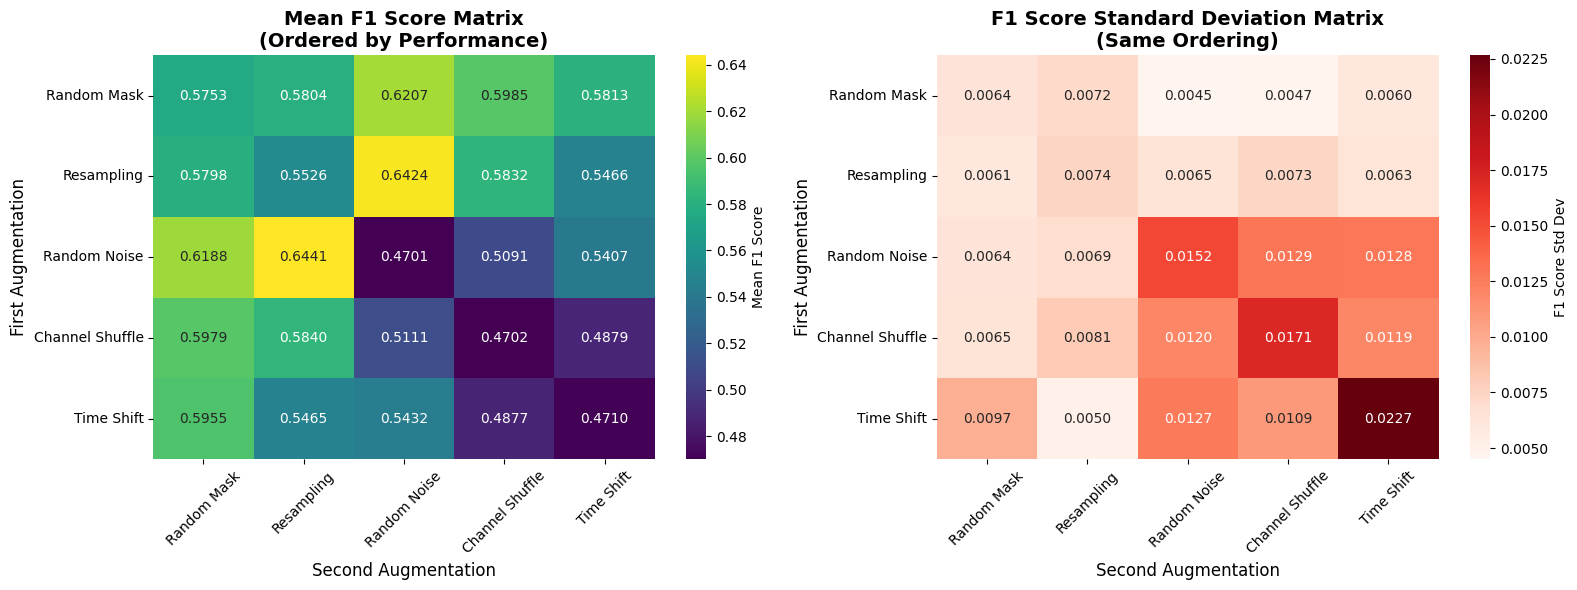


Summary Statistics:
Highest mean F1: 0.6441
Lowest mean F1: 0.4701
Overall mean F1: 0.5575
Mean std deviation: 0.0093


In [29]:
# Create figure with subplots for mean and std
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Mean F1 Score Heatmap
sns.heatmap(f1_mean_pivot_ordered, 
           annot=True, 
           fmt='.4f', 
           cmap='viridis',
           cbar_kws={'label': 'Mean F1 Score'},
           ax=ax1)
ax1.set_title('Mean F1 Score Matrix\n(Ordered by Performance)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Second Augmentation', fontsize=12)
ax1.set_ylabel('First Augmentation', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# Standard Deviation Heatmap
sns.heatmap(f1_std_pivot_ordered, 
           annot=True, 
           fmt='.4f', 
           cmap='Reds',
           cbar_kws={'label': 'F1 Score Std Dev'},
           ax=ax2)
ax2.set_title('F1 Score Standard Deviation Matrix\n(Same Ordering)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Second Augmentation', fontsize=12)
ax2.set_ylabel('First Augmentation', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"Highest mean F1: {f1_mean_pivot_ordered.max().max():.4f}")
print(f"Lowest mean F1: {f1_mean_pivot_ordered.min().min():.4f}")
print(f"Overall mean F1: {f1_mean_pivot_ordered.mean().mean():.4f}")
print(f"Mean std deviation: {f1_std_pivot_ordered.mean().mean():.4f}")

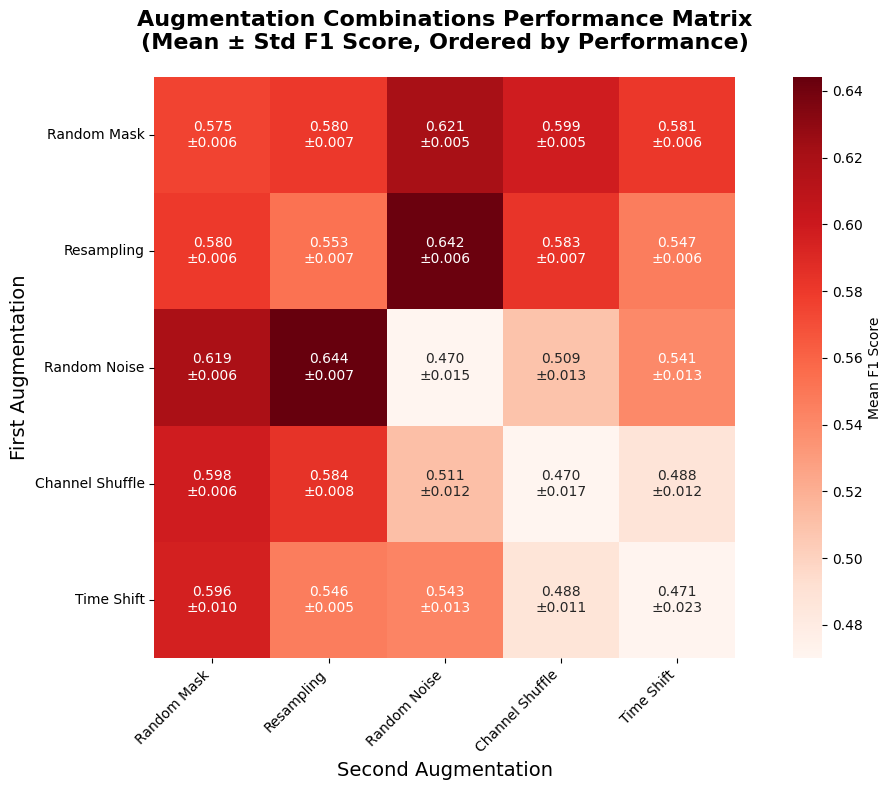

In [30]:
# Create a combined annotation matrix with mean ± std
combined_annotations = f1_mean_pivot_ordered.copy().astype(object)
for i in range(combined_annotations.shape[0]):
    for j in range(combined_annotations.shape[1]):
        mean_val = f1_mean_pivot_ordered.iloc[i, j]
        std_val = f1_std_pivot_ordered.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            combined_annotations.iloc[i, j] = f"{mean_val:.3f}\n±{std_val:.3f}"
        else:
            combined_annotations.iloc[i, j] = "N/A"

# Create combined heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(f1_mean_pivot_ordered, 
           annot=combined_annotations, 
           fmt='',
           cmap='Reds',
           cbar_kws={'label': 'Mean F1 Score'},
           square=True)
plt.title('Augmentation Combinations Performance Matrix\n(Mean ± Std F1 Score, Ordered by Performance)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Second Augmentation', fontsize=14)
plt.ylabel('First Augmentation', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

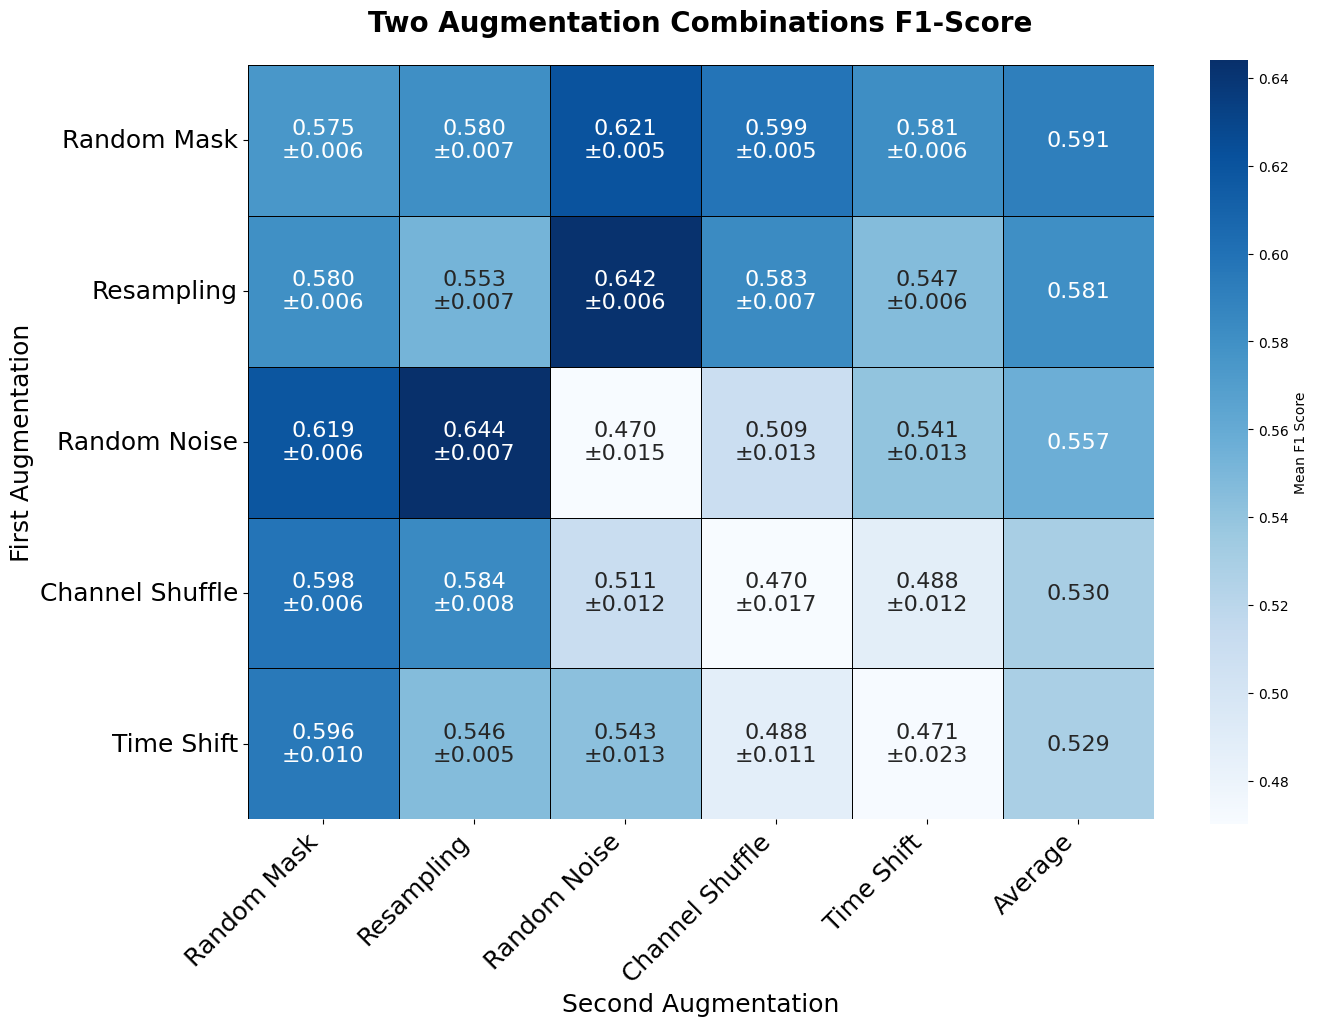


Row Means (First Augmentation Performance):
  Random Mask    : 0.5912
  Resampling     : 0.5809
  Random Noise   : 0.5565
  Channel Shuffle: 0.5302
  Time Shift     : 0.5288

Overall Mean F1 Score: 0.5575


In [ ]:
# Create enhanced heatmap with row means only
# Calculate means for rows
row_means_values = f1_mean_pivot_ordered.mean(axis=1)

# Create extended matrix with row means only
extended_data = f1_mean_pivot_ordered.copy()
extended_data['Average'] = row_means_values

# Create annotations for the extended matrix
extended_annotations = extended_data.copy().astype(object)
for i in range(extended_data.shape[0]):
    for j in range(extended_data.shape[1]):
        if j < len(f1_mean_pivot_ordered.columns):
            # Original data with std
            mean_val = f1_mean_pivot_ordered.iloc[i, j]
            std_val = f1_std_pivot_ordered.iloc[i, j]
            if pd.notna(mean_val) and pd.notna(std_val):
                extended_annotations.iloc[i, j] = f"{mean_val:.3f}\n±{std_val:.3f}"
            else:
                extended_annotations.iloc[i, j] = "N/A"
        else:
            # Row mean values (no std for means)
            val = extended_data.iloc[i, j]
            if pd.notna(val):
                extended_annotations.iloc[i, j] = f"{val:.3f}"
            else:
                extended_annotations.iloc[i, j] = "N/A"

# Create the enhanced heatmap with larger font sizes
plt.figure(figsize=(14, 10))
sns.heatmap(
    extended_data, 
    annot=extended_annotations, 
    fmt='', 
    cmap='Blues',
    cbar_kws={'label': 'Mean F1 Score'},
    square=True,
    linewidths=0.5,
    linecolor='black',
    annot_kws={"size": 16}
)

plt.title(
    'Two Augmentation Combinations F1-Score', 
    fontsize=20, fontweight='bold', pad=24
)
plt.xlabel('Second Augmentation', fontsize=18)
plt.ylabel('First Augmentation', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(rotation=0, fontsize=18)

# Add visual separation for row means column
ax = plt.gca()
# Vertical line to separate means column
#ax.axvline(x=len(f1_mean_pivot_ordered.columns), color='red', linewidth=2)

plt.tight_layout()
plt.savefig('two_augs_analisis.pdf', dpi=300, bbox_inches='tight'f)
plt.show()

print(f"\nRow Means (First Augmentation Performance):")
for aug, score in row_means_values.items():
    print(f"  {aug:15s}: {score:.4f}")

print(f"\nOverall Mean F1 Score: {f1_mean_pivot_ordered.mean().mean():.4f}")

In [32]:
# Find top performing combinations
top_combinations = []
for first_aug in f1_mean_pivot_ordered.index:
    for second_aug in f1_mean_pivot_ordered.columns:
        mean_f1 = f1_mean_pivot_ordered.loc[first_aug, second_aug]
        std_f1 = f1_std_pivot_ordered.loc[first_aug, second_aug]
        if pd.notna(mean_f1):
            top_combinations.append({
                'first_aug': first_aug,
                'second_aug': second_aug,
                'mean_f1': mean_f1,
                'std_f1': std_f1
            })

# Sort by mean F1 and display top combinations
top_combinations_df = pd.DataFrame(top_combinations).sort_values('mean_f1', ascending=False)

print("Top 10 Augmentation Combinations:")
print("="*50)
for i, row in top_combinations_df.head(10).iterrows():
    print(f"{i+1:2d}. {row['first_aug']:15s} + {row['second_aug']:15s} | "
          f"F1: {row['mean_f1']:.4f} ± {row['std_f1']:.4f}")

print(f"\nWorst 5 Augmentation Combinations:")
print("="*50)
for i, row in top_combinations_df.tail(5).iterrows():
    rank = len(top_combinations_df) - top_combinations_df.tail(5).index.get_loc(i)
    print(f"{rank:2d}. {row['first_aug']:15s} + {row['second_aug']:15s} | "
          f"F1: {row['mean_f1']:.4f} ± {row['std_f1']:.4f}")

# Create a summary table of individual augmentation performance
print(f"\nIndividual Augmentation Analysis:")
print("="*50)
print("First Augmentation Performance (mean across all second augs):")
for aug, score in row_means.items():
    print(f"  {aug:15s}: {score:.4f}")

print("\nSecond Augmentation Performance (mean across all first augs):")
for aug, score in col_means.items():
    print(f"  {aug:15s}: {score:.4f}")

Top 10 Augmentation Combinations:
12. Random Noise    + Resampling      | F1: 0.6441 ± 0.0069
 8. Resampling      + Random Noise    | F1: 0.6424 ± 0.0065
 3. Random Mask     + Random Noise    | F1: 0.6207 ± 0.0045
11. Random Noise    + Random Mask     | F1: 0.6188 ± 0.0064
 4. Random Mask     + Channel Shuffle | F1: 0.5985 ± 0.0047
16. Channel Shuffle + Random Mask     | F1: 0.5979 ± 0.0065
21. Time Shift      + Random Mask     | F1: 0.5955 ± 0.0097
17. Channel Shuffle + Resampling      | F1: 0.5840 ± 0.0081
 9. Resampling      + Channel Shuffle | F1: 0.5832 ± 0.0073
 5. Random Mask     + Time Shift      | F1: 0.5813 ± 0.0060

Worst 5 Augmentation Combinations:
25. Channel Shuffle + Time Shift      | F1: 0.4879 ± 0.0119
24. Time Shift      + Channel Shuffle | F1: 0.4877 ± 0.0109
23. Time Shift      + Time Shift      | F1: 0.4710 ± 0.0227
22. Channel Shuffle + Channel Shuffle | F1: 0.4702 ± 0.0171
21. Random Noise    + Random Noise    | F1: 0.4701 ± 0.0152

Individual Augmentation Analy